In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression , Lasso , Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor , AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV , train_test_split
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score 





In [153]:
wine_df = pd.read_csv(r"/home/emad-salib/Wine-Quality-Prediction/data/winequality-red.csv")

In [154]:
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [155]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [156]:
wine_df.drop(['free sulfur dioxide' , 'total sulfur dioxide'], axis=1 , inplace=True)
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,0.9978,3.51,0.56,9.4,5


In [157]:
wine_df.isnull().sum()

fixed acidity       0
volatile acidity    0
citric acid         0
residual sugar      0
chlorides           0
density             0
pH                  0
sulphates           0
alcohol             0
quality             0
dtype: int64

In [158]:
wine_df.duplicated().sum()

np.int64(241)

In [159]:
wine_df.drop_duplicates(inplace=True)

In [160]:
wine_df.duplicated().sum()

np.int64(0)

In [161]:
wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,density,pH,sulphates,alcohol,quality
count,1358.000000,1358.000000,1358.000000,1358.000000,1358.000000,1358.000000,1358.000000,1358.000000,1358.000000,1358.000000
mean,8.310898,0.529647,0.272032,2.519146,0.088152,0.996712,3.310007,0.658814,10.430940,5.622239
std,1.737594,0.182993,0.195295,1.343686,0.049384,0.001867,0.154880,0.170682,1.081275,0.823033
min,4.600000,0.120000,0.000000,0.900000,0.012000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,1.003690,4.010000,2.000000,14.900000,8.000000


In [162]:
def detect_outliers_iqr(df):
    outlier_indices = []

    for col in df.columns:
        if col == 'quality':
            continue

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)].index
        outlier_indices.extend(outliers)

    return set(outlier_indices)

In [163]:
outliers = detect_outliers_iqr(wine_df)

wine_df_clean = wine_df.drop(index=outliers)

print("Original:", wine_df.shape)
print("After removing outliers:", wine_df_clean.shape)

Original: (1358, 10)
After removing outliers: (1059, 10)


In [164]:
X = wine_df.drop('quality' , axis=1)
y = wine_df['quality']

# Train and split data

In [165]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [166]:
X_train.shape, y_train.shape

((1086, 9), (1086,))

In [167]:
X_test.shape , y_test.shape

((272, 9), (272,))

In [168]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [169]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square


In [170]:

models = {
    "Linear Regression": LinearRegression(),

    "Lasso": Lasso(),

    "Ridge": Ridge(),

    "K-Neighbors Regressor": KNeighborsRegressor(),

    "Decision Tree": DecisionTreeRegressor(max_depth=5),

    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    "XGBRegressor": XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    ),

    "CatBoosting Regressor": CatBoostRegressor(
        iterations=300,   # same as n_estimators
        depth=6,          # same as max_depth
        learning_rate=0.1,
        verbose=False
    ),

    "AdaBoost Regressor": AdaBoostRegressor(
        n_estimators=200,
        random_state=42
    )
}

In [171]:
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')


Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.6614
- Mean Absolute Error: 0.5176
- R2 Score: 0.3447
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.6574
- Mean Absolute Error: 0.5078
- R2 Score: 0.3937


Lasso
Model performance for Training set
- Root Mean Squared Error: 0.8170
- Mean Absolute Error: 0.6902
- R2 Score: 0.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.8453
- Mean Absolute Error: 0.7067
- R2 Score: -0.0025


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.6614
- Mean Absolute Error: 0.5176
- R2 Score: 0.3447
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.6573
- Mean Absolute Error: 0.5078
- R2 Score: 0.3938


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 0.5722
- Mean Absolute Error: 0.4330
- R2 Score: 0.5095
----------------------

Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 0.3438
- Mean Absolute Error: 0.2768
- R2 Score: 0.8229
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.6417
- Mean Absolute Error: 0.4929
- R2 Score: 0.4224


XGBRegressor
Model performance for Training set
- Root Mean Squared Error: 0.0682
- Mean Absolute Error: 0.0464
- R2 Score: 0.9930
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.7083
- Mean Absolute Error: 0.5526
- R2 Score: 0.2961


CatBoosting Regressor
Model performance for Training set
- Root Mean Squared Error: 0.3440
- Mean Absolute Error: 0.2699
- R2 Score: 0.8227
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.6642
- Mean Absolute Error: 0.5140
- R2 Score: 0.3811


AdaBoost Regressor
Model performance for Training set
- Root Mean Squared Error: 0.6131
- Mean Absolute Error: 0.5190
- R2 Score: 0.43

In [172]:
pd.DataFrame(list(zip(model_list , r2_list)) , columns=['Model Name' , 'R2_Score']).sort_values(by=['R2_Score'] , ascending=False)

,Model Name,R2_Score
5,Random Forest Regressor,0.422384
2,Ridge,0.393817
0,Linear Regression,0.393737
7,CatBoosting Regressor,0.381145
8,AdaBoost Regressor,0.352904
4,Decision Tree,0.346142
3,K-Neighbors Regressor,0.314223
6,XGBRegressor,0.296142
1,Lasso,-0.002536


In [173]:
lr_model = LinearRegression(fit_intercept=True)
lr_model.fit(X_train , y_train)
y_pred = lr_model.predict(X_test)
score = r2_score(y_test , y_pred)*100
print(f"The Model of Accuracy is %.2f"%score)

The Model of Accuracy is 39.37


# Visualization

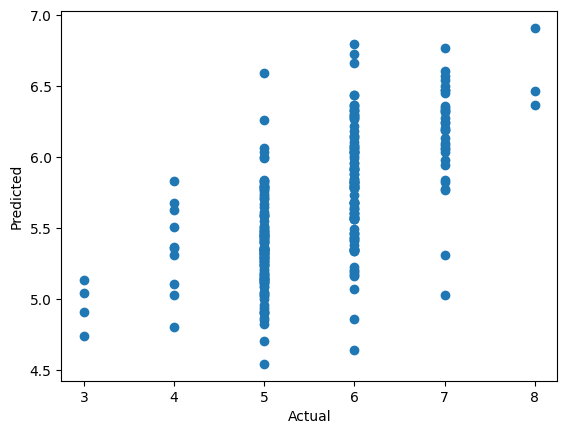

In [174]:
plt.scatter(y_test , y_pred )
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()



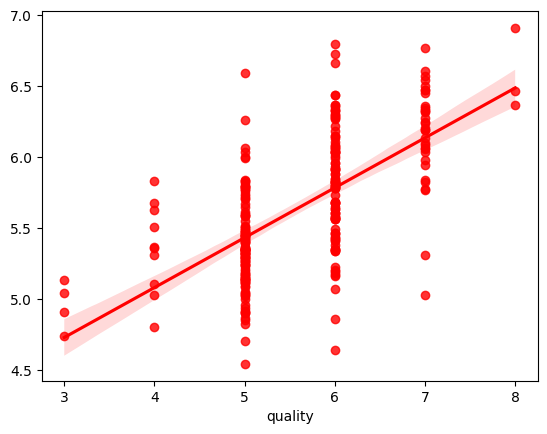

In [178]:
sns.regplot( data = wine_df , x= y_test , y = y_pred , color = 'red')
plt.show()

In [181]:
pred_df = pd.DataFrame({'Actual Value':y_test , 'Predicted Value': y_pred , 'Difference': y_test - y_pred})


In [182]:
pred_df

,Actual Value,Predicted Value,Difference
55,5,5.176649,-0.176649
1291,6,5.827368,0.172632
1544,7,6.245602,0.754398
593,5,5.113706,-0.113706
1090,8,6.463160,1.536840
...,...,...,...
1086,7,6.194737,0.805263
662,6,5.415125,0.584875
279,7,5.841108,1.158892
1111,7,6.034505,0.965495
